##**Overview about Our Project**

**The code implements and compares three types of neural networks (FNN, CNN, and RNN) to classify breast cancer tumors as benign or malignant using the Breast Cancer dataset.**

**1- Feedforward Neural Network (FNN): A simple network with fully connected layers. It learns static relationships between features.**

**2- Convolutional Neural Network (CNN): Uses 1D convolution to capture local patterns in the features. Typically used for spatial data, but here adapted to a 1D structure.**

**3- Recurrent Neural Network (RNN): Specifically, an LSTM network, which captures sequential relationships between data points. Even though the dataset is not time-dependent, it treats features as sequences for comparison.**


**The models are trained using the Adam optimizer and binary cross-entropy loss. Their performance is evaluated using classification metrics like accuracy, precision, recall, and F1-score.**



##**Objectives**

**1- Apply Different Neural Network Architectures to a binary classification problem.**

**2- Preprocess and Standardize Data and visualize correlations.**

**3- Train and Compare Models based on performance metrics.**

**4- Visualize Training Curves to understand model learning behavior.**

**5- Select the Best Model for breast cancer classification based on accuracy and other metrics.**




#**Installition**

In [ ]:
pip install tensorflow

##**Importing libraries**


In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# TensorFlow and Keras libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM

##**Loading The Data**

In [ ]:
# 1. Load the Breast Cancer dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


###**Exploration and Check The cleaning data**

In [ ]:
# 2. Data exploration
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.shape

(569, 31)

In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
df.notnull().sum()

,0
mean radius,569
mean texture,569
mean perimeter,569
mean area,569
mean smoothness,569
mean compactness,569
mean concavity,569
mean concave points,569
mean symmetry,569
mean fractal dimension,569


##**Visualizing Dataset**

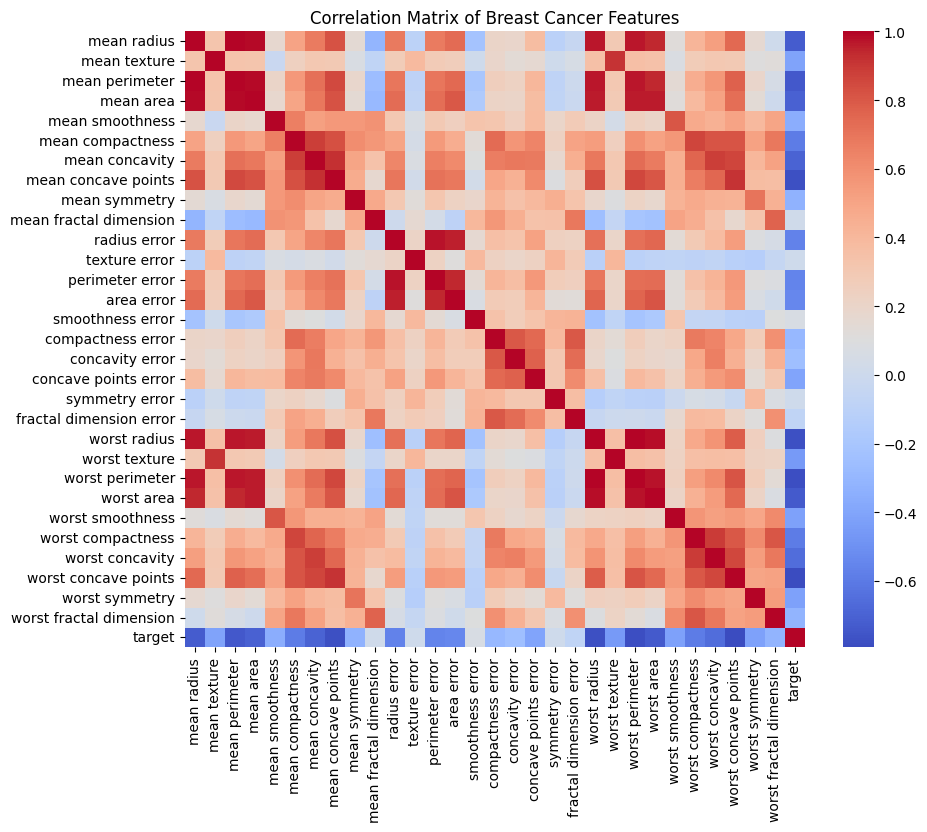

In [ ]:
# Visualizing correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Breast Cancer Features')
plt.show()

##**Prepration The Data**

In [ ]:
# 3. Data Preprocessing
# Splitting the data into features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

**X holds all the independent variables (features).**

**y holds the dependent variable (the target you want to predict).**

##**Spliting The Models**

In [ ]:
# Splitting the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshaping data for CNN (treating as a 1D image with 30 channels/features)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Reshaping data for RNN (treating as a sequence)
X_train_rnn = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_rnn = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

**Purpose of Split Method : The dataset is split into two parts: 80% for training the model (X_train, y_train) and 20% for testing it (X_test, y_test). The  test_size=0.2 argument specifies that 20% of the data will be used for testing.**


**Purpose of Standardizing Method : Standardization scales the features so they have a mean of 0 and a standard deviation of 1, which is important for many machine learning models**.


**Reshaping data for CNN :  CNNs expect input data in a specific format. This step reshapes the data into a 3D format, where each row of data (each sample) is treated as a "1D image" with 30 channels/features.**


**Reshaping data for RNN : RNNs treat data as sequences. This reshapes the data into a 3D format that is suitable for RNNs, where each sample is treated as a sequence with 1 time step and 30 features.**



##**Building The Models**

In [ ]:
# 4. Model Building

# FNN Model
fnn_model = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# CNN Model
cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=X_train_cnn.shape[1:]),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# RNN Model
rnn_model = Sequential([
    LSTM(64, input_shape=X_train_rnn.shape[1:], return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile all models with the same optimizer and loss function
models = [fnn_model, cnn_model, rnn_model]
for model in models:
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**FNN : A basic fully connected feedforward neural network with 64 and 32 neurons in hidden layers.**

**CNN : A convolutional neural network that uses 1D convolution for feature extraction from sequential data, followed by fully connected layers.**

**RNN : A recurrent neural network using an LSTM layer for handling sequential dependencies in the data, followed by fully connected layers.**


**Compilation : All models are compiled with the Adam optimizer, binary cross-entropy loss for classification, and accuracy as the evaluation metric.**

##**Training**

In [ ]:
# 5. Training the Models

history_fnn = fnn_model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2, batch_size=32, verbose=1)
history_cnn = cnn_model.fit(X_train_cnn, y_train, epochs=20, validation_split=0.2, batch_size=32, verbose=1)
history_rnn = rnn_model.fit(X_train_rnn, y_train, epochs=20, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6984 - loss: 0.6426 - val_accuracy: 0.8791 - val_loss: 0.4122
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9166 - loss: 0.3874 - val_accuracy: 0.9451 - val_loss: 0.2694
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9580 - loss: 0.2312 - val_accuracy: 0.9560 - val_loss: 0.1978
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9623 - loss: 0.1685 - val_accuracy: 0.9560 - val_loss: 0.1615
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9633 - loss: 0.1323 - val_accuracy: 0.9560 - val_loss: 0.1426
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9631 - loss: 0.1235 - val_accuracy: 0.9560 - val_loss: 0.1307
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9836 - loss: 0.0815 - val_accuracy: 0.9560 - val_loss: 0.1233
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9817 - loss: 0.0728 - val_accuracy: 0.9670 - val_loss

##**Create curves (loss)**

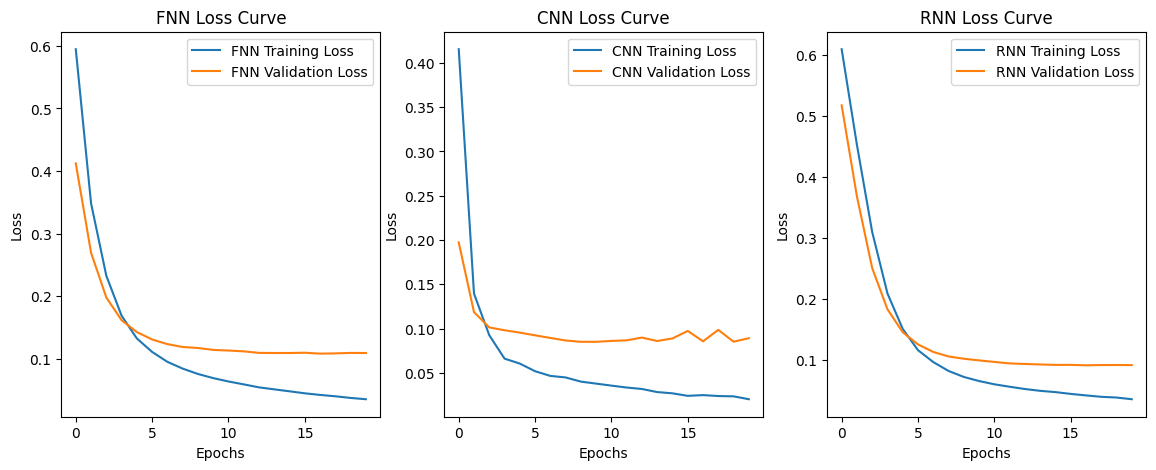

In [ ]:
# 6. Visualizing training curves (loss)
plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
plt.plot(history_fnn.history['loss'], label='FNN Training Loss')
plt.plot(history_fnn.history['val_loss'], label='FNN Validation Loss')
plt.title('FNN Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_cnn.history['loss'], label='CNN Training Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Validation Loss')
plt.title('CNN Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_rnn.history['loss'], label='RNN Training Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss')
plt.title('RNN Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

##**Evaluating the Models**

In [ ]:
# 7. Evaluating the Models
# Predict on test data
y_pred_fnn = (fnn_model.predict(X_test_scaled) > 0.5).astype("int32")
y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype("int32")
y_pred_rnn = (rnn_model.predict(X_test_rnn) > 0.5).astype("int32")

# Classification reports
print("FNN Classification Report:")
print(classification_report(y_test, y_pred_fnn))

print("CNN Classification Report:")
print(classification_report(y_test, y_pred_cnn))

print("RNN Classification Report:")
print(classification_report(y_test, y_pred_rnn))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step
FNN Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

CNN Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

RNN Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro

##**Conclusion**

**This project successfully compares three different neural network architectures—Feedforward Neural Network (FNN), Convolutional Neural Network (CNN), and Recurrent Neural Network (RNN)—on the Breast Cancer dataset. Each model has its strengths and weaknesses:**


**FNN performed as expected, capturing basic relationships between the features but lacks the ability to recognize complex patterns.**

**CNN showed good performance by identifying local patterns in the feature set, making it particularly useful for spatially or structurally arranged data.**


**RNN (LSTM), although designed for sequential data, was able to achieve competitive results, suggesting that it can still extract meaningful patterns from static data.**


**Through training and evaluation, it became clear that model performance varies depending on the data characteristics and the architecture used. Overall, the project demonstrates how different neural networks can be applied to classification problems, and how their performances should be carefully assessed before selecting the best one for practical use.**








